# Pemodelan Prediksi Suhu Permukaan Jawa
## Regresi Multivariat + EXDM Optimizer | Data CORDEX-CMIP5

---

**Dataset**: CORDEX South-East Asia (SEA) — Domain 0.22° × 0.22°  
**Sumber**: Climate Data Store (CDS) Copernicus — https://cds.climate.copernicus.eu/  
**GCM Driver**: MOHC-HadGEM2-ES (CMIP5)  
**RCM**: SMHI-RCA4  
**Skenario**: Historical (1976–2005), RCP4.5, RCP8.5 (2006–2100)  
**Area**: Pulau Jawa — BBox lat[-8.8, -5.9] lon[105.1, 115.7]  

---

### Referensi Utama
- Tangang et al. (2020) — CORDEX-SEA: *An integrated regional climate model projection for Southeast Asia* — Climate Dynamics
- Beucler et al. (2021) — *Climate-Invariant Machine Learning* — arXiv:2112.08440
- Li et al. (2010) — EDCDF Bias Correction — J. Hydrology
- Ghaemi et al. (2023) — Regional Temperature Projection arXiv:2504.19145

---

In [ ]:

# SETUP — Import libraries 

import sys, os
sys.path.insert(0, '../tools')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Tools proyek
from train_model import (
    MultivariateRegressionModel,
    EXDMOptimizer,
    ZScoreNormalizer
)
from bias_corrector import EDCDFBiasCorrector
from feature_engineer import (
    seasonal_encoding,
    compute_climatology,
    add_lag_features,
    add_rolling_features
)

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
print('Setup selesai ✓')

Setup selesai ✓


---
## 1. Eksplorasi Data (EDA)

In [25]:
# ── Load data (gunakan dummy jika NC belum diunduh) ───────────────
DATA_PATH = '../data/processed/features/X_historical.csv'
TARGET_PATH = '../data/processed/targets/y_historical.csv'

if os.path.exists(DATA_PATH):
    df_X = pd.read_csv(DATA_PATH, parse_dates=['time'])
    df_y = pd.read_csv(TARGET_PATH, parse_dates=['time'])
    print(f'Data dimuat: X={df_X.shape} | y={df_y.shape}')
else:
    # Generate data dummy untuk demonstrasi
    print('[DEMO] Menggunakan data sintetik (CORDEX belum diunduh)...')
    n = 360  # 30 tahun × 12 bulan
    dates = pd.date_range('1976-01-01', periods=n, freq='MS')
    t = np.arange(n)
    seasonal = np.sin(2 * np.pi * t / 12)
    trend    = 0.003 * t  # pemanasan ~0.3°C/dekade

    df_raw = pd.DataFrame({
        'time':      dates,
        'temp_2m':   27.0 + 1.5 * seasonal + trend + np.random.normal(0, 0.25, n),
        'precip':    8.5  + 4.0 * seasonal + np.random.normal(0, 1.0, n),
        'pressure':  1010 + 2.0 * seasonal + np.random.normal(0, 0.5, n),
        'humidity':  80.0 + 5.0 * seasonal + np.random.normal(0, 2.0, n),
        'wind_u':    1.5  + 0.5 * seasonal + np.random.normal(0, 0.2, n),
        'wind_v':    0.8  + 0.3 * seasonal + np.random.normal(0, 0.2, n),
        'radiation': 200  + 50  * seasonal + np.random.normal(0, 10,  n),
    })
    print(f'Data sintetik: {df_raw.shape}')
    df_raw.head()

[DEMO] Menggunakan data sintetik (CORDEX belum diunduh)...
Data sintetik: (360, 8)


In [26]:
# ── Statistik deskriptif ──────────────────────────────────────────
df_raw.describe().round(3)

,time,temp_2m,precip,pressure,humidity,wind_u,wind_v,radiation
count,360,360.000,360.000,360.000,360.000,360.000,360.000,360.000
mean,1990-12-16 05:20:00,27.539,8.478,1010.055,80.141,1.516,0.795,200.162
min,1976-01-01 00:00:00,25.335,2.339,1006.901,69.207,0.526,-0.064,127.807
25%,1983-06-23 12:00:00,26.576,5.952,1008.738,76.750,1.170,0.569,167.188
50%,1990-12-16 12:00:00,27.517,8.548,1010.059,79.909,1.545,0.792,197.826
75%,1998-06-08 12:00:00,28.477,11.206,1011.455,83.357,1.854,1.015,233.986
max,2005-12-01 00:00:00,29.922,14.410,1013.071,89.153,2.512,1.589,270.895
std,NaN,1.124,3.010,1.534,4.142,0.406,0.293,36.184


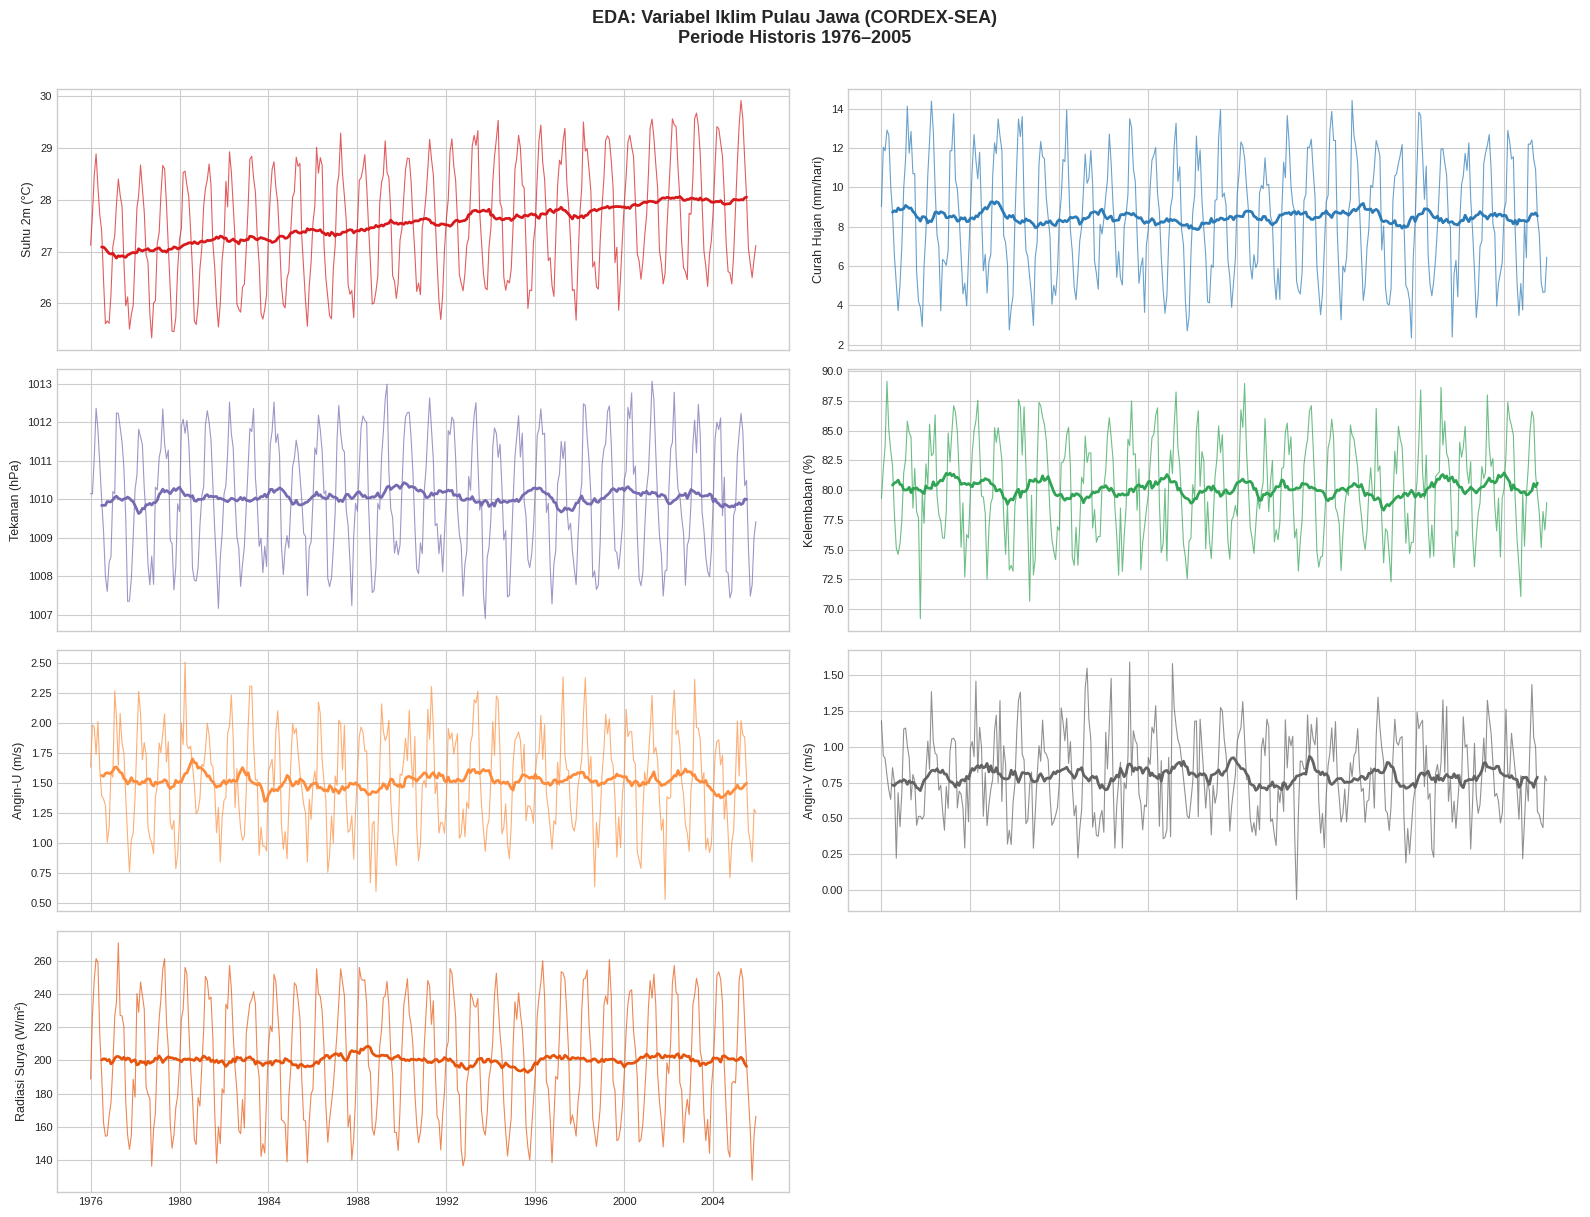

In [27]:
# ── Visualisasi EDA: Time Series Semua Variabel ───────────────────
fig, axes = plt.subplots(4, 2, figsize=(16, 12), sharex=True)
axes = axes.flatten()

variables = [
    ('temp_2m',   'Suhu 2m (°C)',         '#d7191c'),
    ('precip',    'Curah Hujan (mm/hari)', '#2c7bb6'),
    ('pressure',  'Tekanan (hPa)',         '#756bb1'),
    ('humidity',  'Kelembaban (%)',        '#31a354'),
    ('wind_u',    'Angin-U (m/s)',         '#fd8d3c'),
    ('wind_v',    'Angin-V (m/s)',         '#636363'),
    ('radiation', 'Radiasi Surya (W/m²)', '#e6550d'),
]

for i, (col, label, color) in enumerate(variables):
    if col in df_raw.columns:
        axes[i].plot(df_raw['time'], df_raw[col], color=color,
                     linewidth=0.8, alpha=0.7)
        roll = df_raw[col].rolling(12, center=True).mean()
        axes[i].plot(df_raw['time'], roll, color=color,
                     linewidth=2.0)
        axes[i].set_ylabel(label, fontsize=9)
        axes[i].tick_params(labelsize=8)

axes[-1].set_visible(False)
fig.suptitle('EDA: Variabel Iklim Pulau Jawa (CORDEX-SEA)\n'
             'Periode Historis 1976–2005',
             fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
plt.savefig('../results/figures/eda_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

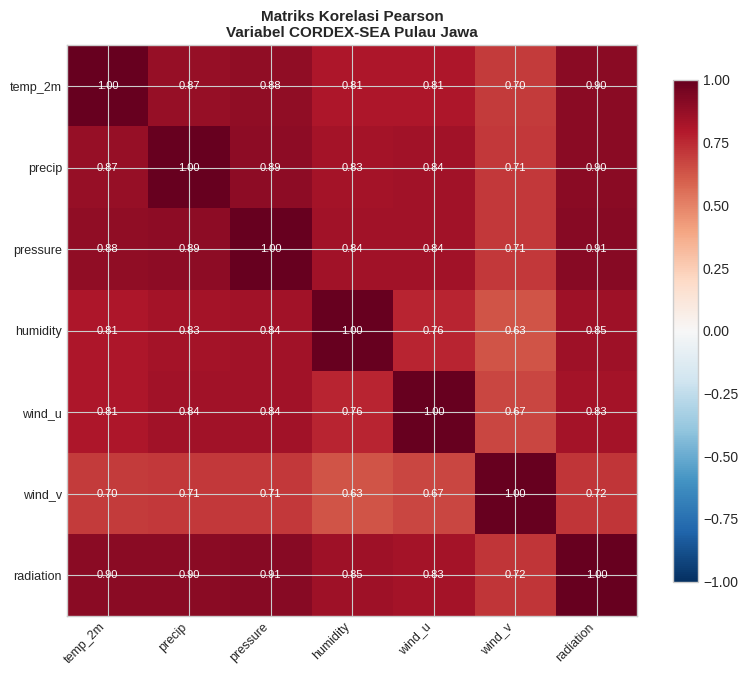

In [28]:
# ── Matriks Korelasi (NumPy scratch) ─────────────────────────────
num_cols = [c for c in df_raw.columns if c != 'time']
X_all = df_raw[num_cols].values

# Hitung korelasi Pearson dari scratch
n_vars = X_all.shape[1]
corr_matrix = np.zeros((n_vars, n_vars))
for i in range(n_vars):
    for j in range(n_vars):
        xi = X_all[:, i] - X_all[:, i].mean()
        xj = X_all[:, j] - X_all[:, j].mean()
        denom = np.sqrt(np.sum(xi**2) * np.sum(xj**2))
        corr_matrix[i, j] = np.sum(xi * xj) / denom if denom > 0 else 0

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(n_vars))
ax.set_yticks(range(n_vars))
ax.set_xticklabels(num_cols, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(num_cols, fontsize=9)

for i in range(n_vars):
    for j in range(n_vars):
        ax.text(j, i, f'{corr_matrix[i, j]:.2f}',
                ha='center', va='center', fontsize=8,
                color='white' if abs(corr_matrix[i, j]) > 0.5 else 'black')

plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Matriks Korelasi Pearson\nVariabel CORDEX-SEA Pulau Jawa',
             fontsize=11, fontweight='bold')
fig.tight_layout()
plt.savefig('../results/figures/eda_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. Bias Correction (EDCDF)

In [29]:
# ── Demonstrasi EDCDF Bias Correction ────────────────────────────
# Simulasi: obs_hist = ERA5, mod_hist = CORDEX historis
np.random.seed(0)
obs_hist = df_raw['temp_2m'].values + np.random.normal(0, 0.1, len(df_raw))
mod_hist = df_raw['temp_2m'].values + 1.2  # Bias sistematik +1.2°C

# Proyeksi RCP (simulasi)
n_proj = 200
t_proj = np.arange(n_proj)
seasonal_proj = np.sin(2 * np.pi * t_proj / 12)
trend_proj = 0.005 * t_proj
mod_proj = 28.0 + 1.5 * seasonal_proj + trend_proj + 1.2 + np.random.normal(0, 0.3, n_proj)

# Terapkan EDCDF
corrector = EDCDFBiasCorrector(n_quantiles=100)
corrected = corrector.fit_transform(obs_hist, mod_hist, mod_proj)

print(f'Sebelum koreksi: mean={mod_proj.mean():.3f}°C')
print(f'Sesudah koreksi: mean={corrected.mean():.3f}°C')
print(f'Referensi hist:  mean={obs_hist.mean():.3f}°C')

Sebelum koreksi: mean=29.695°C
Sesudah koreksi: mean=28.490°C
Referensi hist:  mean=27.537°C


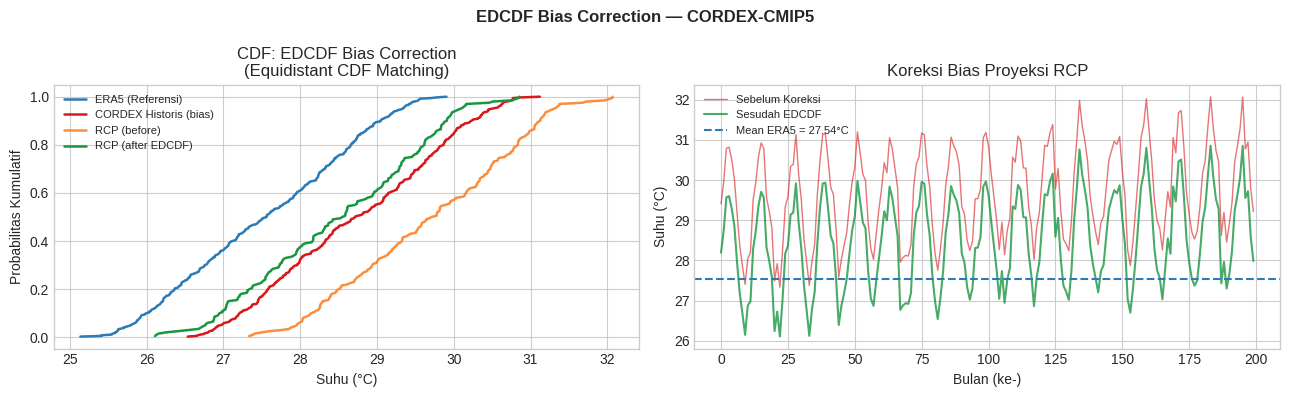

In [30]:
# ── Plot CDF sebelum/sesudah koreksi ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# CDF
for arr, label, color in [
    (obs_hist, 'ERA5 (Referensi)', '#2c7bb6'),
    (mod_hist, 'CORDEX Historis (bias)', '#d7191c'),
    (mod_proj[:len(obs_hist)], 'RCP (before)', '#fd8d3c'),
    (corrected[:len(obs_hist)], 'RCP (after EDCDF)', '#1a9641'),
]:
    sorted_arr = np.sort(arr[:360])
    p = np.arange(1, len(sorted_arr)+1) / len(sorted_arr)
    axes[0].plot(sorted_arr, p, label=label, color=color, linewidth=1.8)

axes[0].set_xlabel('Suhu (°C)')
axes[0].set_ylabel('Probabilitas Kumulatif')
axes[0].set_title('CDF: EDCDF Bias Correction\n(Equidistant CDF Matching)')
axes[0].legend(fontsize=8)

# Time series perbandingan
t_range = np.arange(n_proj)
axes[1].plot(t_range, mod_proj, color='#d7191c', alpha=0.6,
             linewidth=1, label='Sebelum Koreksi')
axes[1].plot(t_range, corrected, color='#1a9641', alpha=0.8,
             linewidth=1.5, label='Sesudah EDCDF')
axes[1].axhline(obs_hist.mean(), color='#2c7bb6', linestyle='--',
                linewidth=1.5, label=f'Mean ERA5 = {obs_hist.mean():.2f}°C')
axes[1].set_xlabel('Bulan (ke-)')
axes[1].set_ylabel('Suhu (°C)')
axes[1].set_title('Koreksi Bias Proyeksi RCP')
axes[1].legend(fontsize=8)

fig.suptitle('EDCDF Bias Correction — CORDEX-CMIP5', fontsize=12, fontweight='bold')
fig.tight_layout()
plt.savefig('../results/figures/bias_correction_edcdf.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Feature Engineering

In [31]:
# ── Feature Engineering ──────────────────────────────────────────
df = df_raw.copy()

# Seasonal encoding
months = df['time'].dt.month.values
df['sin_month'], df['cos_month'] = seasonal_encoding(months)
df['month'] = months
df['year']  = df['time'].dt.year

# Lag features
df = add_lag_features(df, 'temp_2m',  lags=[1, 2, 3, 6, 12])
df = add_lag_features(df, 'precip',   lags=[1, 3, 6])
df = add_lag_features(df, 'humidity', lags=[1, 3])
df = add_lag_features(df, 'pressure', lags=[1, 2])

# Rolling mean
df = add_rolling_features(df, 'temp_2m', windows=[3, 6, 12])
df = add_rolling_features(df, 'precip',  windows=[3, 12])

# Kecepatan angin
df['wind_speed'] = np.sqrt(df['wind_u']**2 + df['wind_v']**2)
df['wind_dir']   = np.degrees(np.arctan2(df['wind_v'], df['wind_u'])) % 360

# Anomali suhu
df['temp_anomaly'] = compute_climatology(df['temp_2m'], df['time']).values

# Gradient temporal
df['temp_gradient_1m'] = df['temp_2m'].diff(1)
df['temp_gradient_3m'] = df['temp_2m'].diff(3)

# Hapus NaN dari lag
df = df.dropna().reset_index(drop=True)

print(f'Fitur setelah engineering: {df.shape}')
print(f'Kolom: {list(df.columns)}')

Fitur setelah engineering: (348, 34)
Kolom: ['time', 'temp_2m', 'precip', 'pressure', 'humidity', 'wind_u', 'wind_v', 'radiation', 'sin_month', 'cos_month', 'month', 'year', 'temp_2m_lag1', 'temp_2m_lag2', 'temp_2m_lag3', 'temp_2m_lag6', 'temp_2m_lag12', 'precip_lag1', 'precip_lag3', 'precip_lag6', 'humidity_lag1', 'humidity_lag3', 'pressure_lag1', 'pressure_lag2', 'temp_2m_roll3', 'temp_2m_roll6', 'temp_2m_roll12', 'precip_roll3', 'precip_roll12', 'wind_speed', 'wind_dir', 'temp_anomaly', 'temp_gradient_1m', 'temp_gradient_3m']


---
## 4. Persiapan Data Training

In [32]:
# ── Temporal Split ────────────────────────────────────────────────
year = df['time'].dt.year

TRAIN_END = 2000
VAL_END   = 2003

mask_train = year <= TRAIN_END
mask_val   = (year > TRAIN_END) & (year <= VAL_END)
mask_test  = year > VAL_END

TARGET = 'temp_2m'
DROP   = ['time', TARGET]
feature_cols = [c for c in df.columns if c not in DROP]

X_train = df[mask_train][feature_cols].values
y_train = df[mask_train][TARGET].values
X_val   = df[mask_val][feature_cols].values
y_val   = df[mask_val][TARGET].values
X_test  = df[mask_test][feature_cols].values
y_test  = df[mask_test][TARGET].values
t_test  = df[mask_test]['time'].values

print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')
print(f'Periode train: {df[mask_train]["time"].min()} – {df[mask_train]["time"].max()}')
print(f'Periode val  : {df[mask_val]["time"].min()} – {df[mask_val]["time"].max()}')
print(f'Periode test : {df[mask_test]["time"].min()} – {df[mask_test]["time"].max()}')

Train: (288, 32) | Val: (36, 32) | Test: (24, 32)
Periode train: 1977-01-01 00:00:00 – 2000-12-01 00:00:00
Periode val  : 2001-01-01 00:00:00 – 2003-12-01 00:00:00
Periode test : 2004-01-01 00:00:00 – 2005-12-01 00:00:00


In [33]:
# ── Normalisasi Z-score (NumPy scratch) ──────────────────────────
norm_X = ZScoreNormalizer()
X_train_n = norm_X.fit_transform(X_train)
X_val_n   = norm_X.transform(X_val)
X_test_n  = norm_X.transform(X_test)

y_mean, y_std = y_train.mean(), y_train.std()
y_train_n = (y_train - y_mean) / y_std
y_val_n   = (y_val   - y_mean) / y_std
y_test_n  = (y_test  - y_mean) / y_std

print(f'X train normalized: mean={X_train_n.mean():.4f} | std={X_train_n.std():.4f}')
print(f'y train: mean={y_mean:.3f}°C | std={y_std:.3f}°C')

X train normalized: mean=-0.0000 | std=1.0000
y train: mean=27.462°C | std=1.098°C


---
## 5. Training Model: Regresi Multivariat + EXDM Optimizer

In [34]:
# ── Inisialisasi EXDM Optimizer ──────────────────────────────────
optimizer = EXDMOptimizer(
    lr      = 0.01,    # Learning rate awal
    beta1   = 0.90,    # Momentum
    beta2   = 0.999,   # Adaptive accumulator
    decay   = 1e-4,    # Exponential decay rate
    epsilon = 1e-8     # Numerator stabilizer
)

model = MultivariateRegressionModel(
    optimizer  = optimizer,
    l2_lambda  = 1e-4   # Regularisasi Ridge
)

print('Model EXDM siap. Mulai training...')
print(f'Fitur: {X_train_n.shape[1]} | Samples: {len(y_train_n)}')

Model EXDM siap. Mulai training...
Fitur: 32 | Samples: 288


In [35]:
# ── Training ─────────────────────────────────────────────────────
np.random.seed(42)

model.fit(
    X_train_n, y_train_n,
    X_val=X_val_n, y_val=y_val_n,
    epochs     = 500,
    batch_size = 32,
    verbose    = True,
    patience   = 40
)

print(f'\nTotal epoch berjalan: {len(model.loss_history)}')

  Epoch   50/500 | train_loss=0.0029 | val_loss=0.0034
  Epoch  100/500 | train_loss=0.0010 | val_loss=0.0011
  Epoch  150/500 | train_loss=0.0005 | val_loss=0.0005
  Epoch  200/500 | train_loss=0.0003 | val_loss=0.0003
  Epoch  250/500 | train_loss=0.0003 | val_loss=0.0002
  Epoch  300/500 | train_loss=0.0002 | val_loss=0.0002
  Epoch  350/500 | train_loss=0.0002 | val_loss=0.0002
  Epoch  400/500 | train_loss=0.0002 | val_loss=0.0002
  Epoch  450/500 | train_loss=0.0001 | val_loss=0.0001
  Epoch  500/500 | train_loss=0.0002 | val_loss=0.0001

Total epoch berjalan: 500


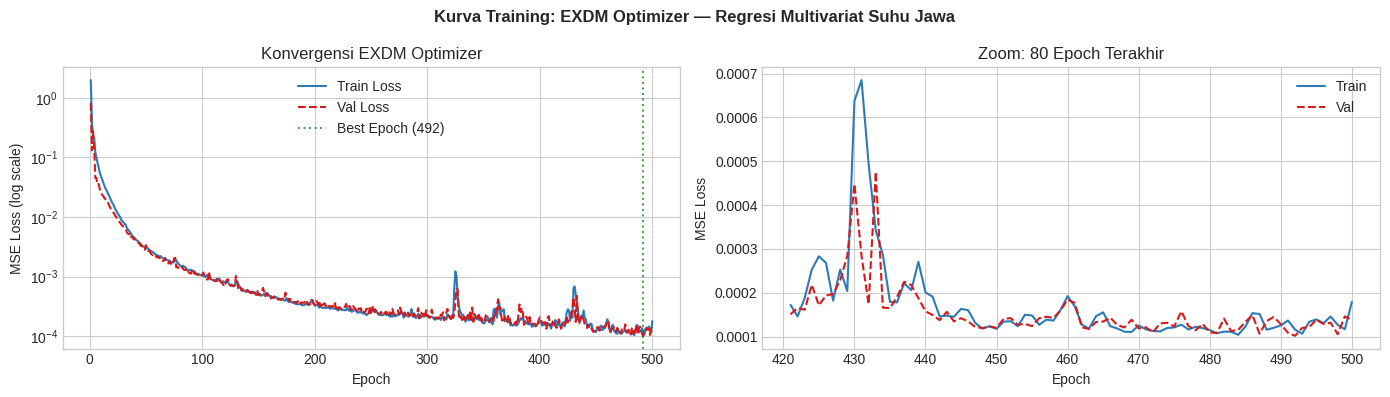

In [36]:
# ── Plot Konvergensi EXDM ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

train_loss = model.loss_history
val_loss   = model.val_loss_history
epochs_t   = np.arange(1, len(train_loss)+1)
epochs_v   = np.linspace(1, len(train_loss), len(val_loss))

# Log scale
axes[0].plot(epochs_t, train_loss, color='#2c7bb6', linewidth=1.5, label='Train Loss')
axes[0].plot(epochs_v, val_loss, color='#d7191c',   linewidth=1.5, linestyle='--', label='Val Loss')
best_ep = int(np.argmin(val_loss) * len(train_loss) / len(val_loss)) + 1
axes[0].axvline(best_ep, color='green', linestyle=':', alpha=0.7, label=f'Best Epoch ({best_ep})')
axes[0].set_yscale('log')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss (log scale)')
axes[0].set_title('Konvergensi EXDM Optimizer')
axes[0].legend()

# Zoom 50 epoch terakhir
last_n = min(80, len(train_loss))
axes[1].plot(epochs_t[-last_n:], train_loss[-last_n:], color='#2c7bb6', linewidth=1.5, label='Train')
if len(val_loss) >= last_n:
    axes[1].plot(epochs_v[-last_n:], val_loss[-last_n:], color='#d7191c', linewidth=1.5,
                 linestyle='--', label='Val')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')
axes[1].set_title(f'Zoom: {last_n} Epoch Terakhir')
axes[1].legend()

fig.suptitle('Kurva Training: EXDM Optimizer — Regresi Multivariat Suhu Jawa',
             fontsize=12, fontweight='bold')
fig.tight_layout()
plt.savefig('../results/figures/training_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Evaluasi Model

In [37]:
# ── Metrik pada Test Set ──────────────────────────────────────────
metrics_test = model.evaluate(X_test_n, y_test_n)
metrics_val  = model.evaluate(X_val_n,  y_val_n)

df_metrics = pd.DataFrame({
    'Metrik': list(metrics_test.keys()),
    'Validasi': list(metrics_val.values()),
    'Test': list(metrics_test.values()),
}).set_index('Metrik')

print('\n=== Metrik Evaluasi Model ===')
print(df_metrics.round(4).to_string())


=== Metrik Evaluasi Model ===
           Validasi    Test
Metrik                     
MSE          0.0000  0.0001
RMSE         0.0062  0.0073
MAE          0.0054  0.0064
R2           1.0000  0.9999
NSE          1.0000  0.9999
MBE          0.0007 -0.0001
Pearson_r    1.0000  1.0000


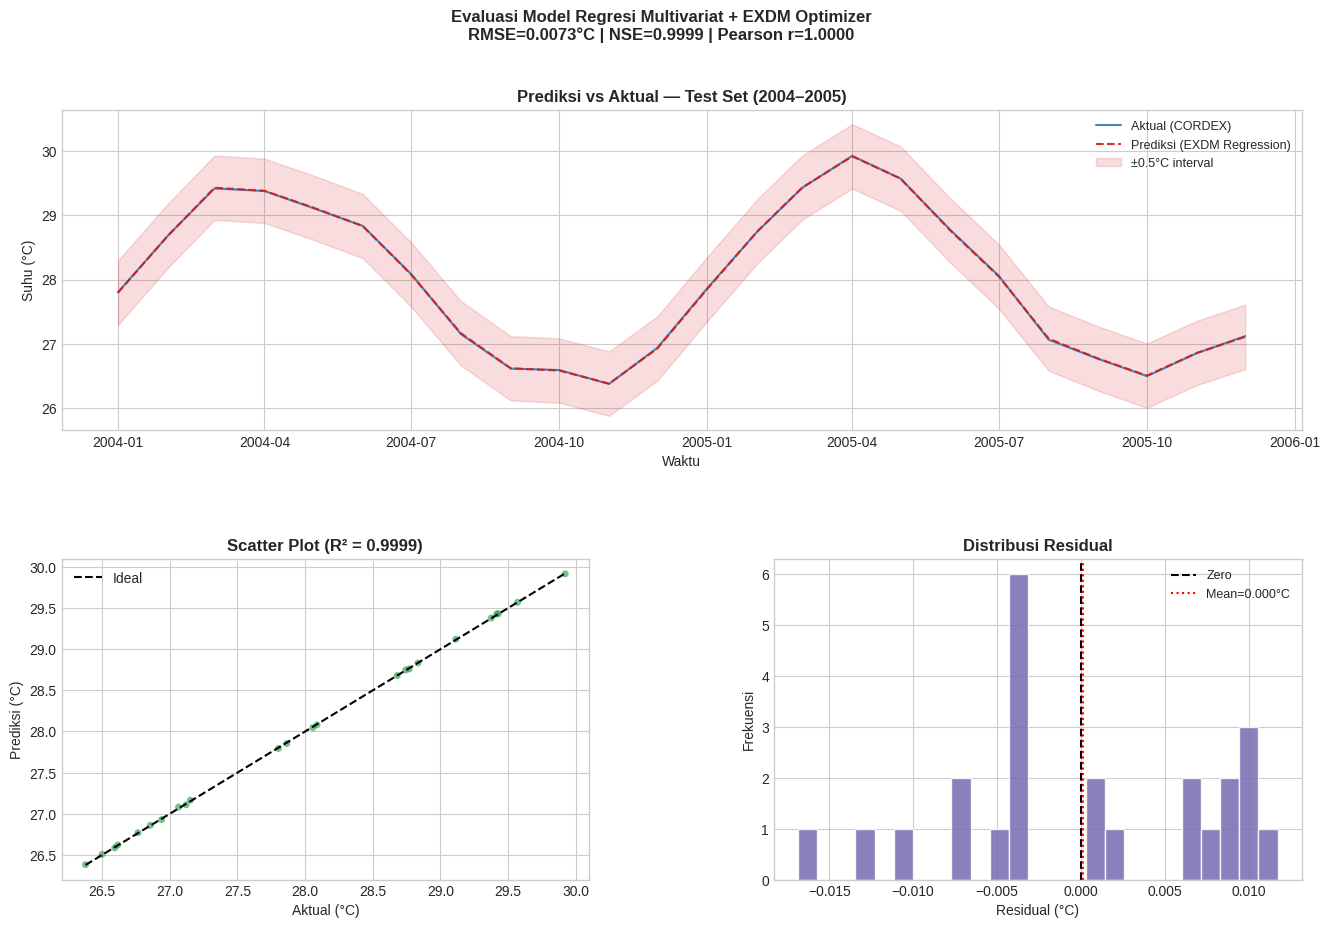

In [38]:
# ── Prediksi vs Aktual ────────────────────────────────────────────
y_test_pred_n = model.predict(X_test_n)
y_test_pred   = y_test_pred_n * y_std + y_mean
residuals     = y_test - y_test_pred

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.35)

# Plot 1: Time series pred vs actual
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(pd.to_datetime(t_test), y_test,      color='#2c7bb6',
         linewidth=1.5, label='Aktual (CORDEX)', alpha=0.9)
ax1.plot(pd.to_datetime(t_test), y_test_pred, color='#d7191c',
         linewidth=1.5, linestyle='--', label='Prediksi (EXDM Regression)', alpha=0.9)
ax1.fill_between(pd.to_datetime(t_test),
                 y_test_pred - 0.5, y_test_pred + 0.5,
                 alpha=0.15, color='#d7191c', label='±0.5°C interval')
ax1.set_xlabel('Waktu')
ax1.set_ylabel('Suhu (°C)')
ax1.set_title('Prediksi vs Aktual — Test Set (2004–2005)', fontweight='bold')
ax1.legend(fontsize=9)

# Plot 2: Scatter
ax2 = fig.add_subplot(gs[1, 0])
ax2.scatter(y_test, y_test_pred, alpha=0.6, s=25, color='#1a9641', edgecolors='none')
lims = [min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max())]
ax2.plot(lims, lims, 'k--', linewidth=1.5, label='Ideal')
r2 = metrics_test['R2']
ax2.set_xlabel('Aktual (°C)')
ax2.set_ylabel('Prediksi (°C)')
ax2.set_title(f'Scatter Plot (R² = {r2:.4f})', fontweight='bold')
ax2.legend()

# Plot 3: Residual histogram
ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(residuals, bins=25, color='#756bb1', edgecolor='white', alpha=0.85)
ax3.axvline(0,              color='black', linestyle='--', linewidth=1.5, label='Zero')
ax3.axvline(residuals.mean(), color='red', linestyle=':', linewidth=1.5,
            label=f'Mean={residuals.mean():.3f}°C')
ax3.set_xlabel('Residual (°C)')
ax3.set_ylabel('Frekuensi')
ax3.set_title('Distribusi Residual', fontweight='bold')
ax3.legend(fontsize=9)

fig.suptitle('Evaluasi Model Regresi Multivariat + EXDM Optimizer\n'
             f'RMSE={metrics_test["RMSE"]:.4f}°C | NSE={metrics_test["NSE"]:.4f} | '
             f'Pearson r={metrics_test["Pearson_r"]:.4f}',
             fontsize=12, fontweight='bold')
plt.savefig('../results/figures/evaluation_result.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Feature Importance

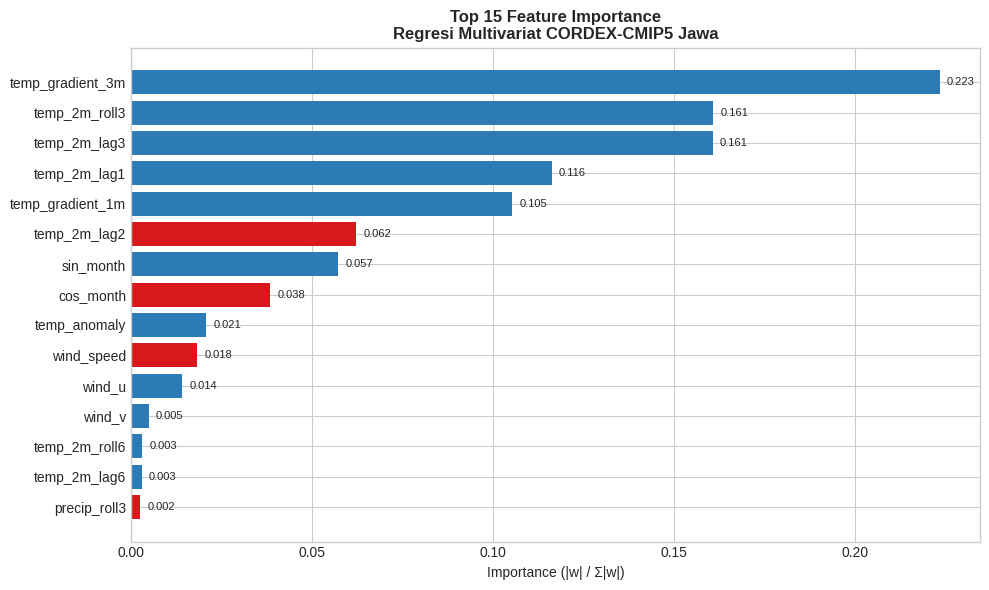


Top 10 features:
         feature    weight  importance
temp_gradient_3m  0.483622    0.223250
   temp_2m_roll3  0.348201    0.160737
    temp_2m_lag3  0.347844    0.160572
    temp_2m_lag1  0.251640    0.116163
temp_gradient_1m  0.227979    0.105240
    temp_2m_lag2 -0.134508    0.062092
       sin_month  0.124042    0.057261
       cos_month -0.083331    0.038468
    temp_anomaly  0.044749    0.020657
      wind_speed -0.039648    0.018302


In [39]:
# ── Feature Importance ────────────────────────────────────────────
fi = model.get_feature_importance(feature_cols)
top15 = fi.head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#d7191c' if w < 0 else '#2c7bb6' for w in top15['weight']]
ax.barh(top15['feature'], top15['importance'], color=colors, edgecolor='none')
ax.set_xlabel('Importance (|w| / Σ|w|)')
ax.set_title('Top 15 Feature Importance\nRegresi Multivariat CORDEX-CMIP5 Jawa',
             fontsize=12, fontweight='bold')
ax.invert_yaxis()

# Annotate
for i, (imp, w) in enumerate(zip(top15['importance'], top15['weight'])):
    ax.text(imp + 0.002, i, f'{imp:.3f}', va='center', fontsize=8)

fig.tight_layout()
plt.savefig('../results/figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 features:')
print(fi[['feature', 'weight', 'importance']].head(10).to_string(index=False))

---
## 8. Simulasi Proyeksi Suhu 2006–2100

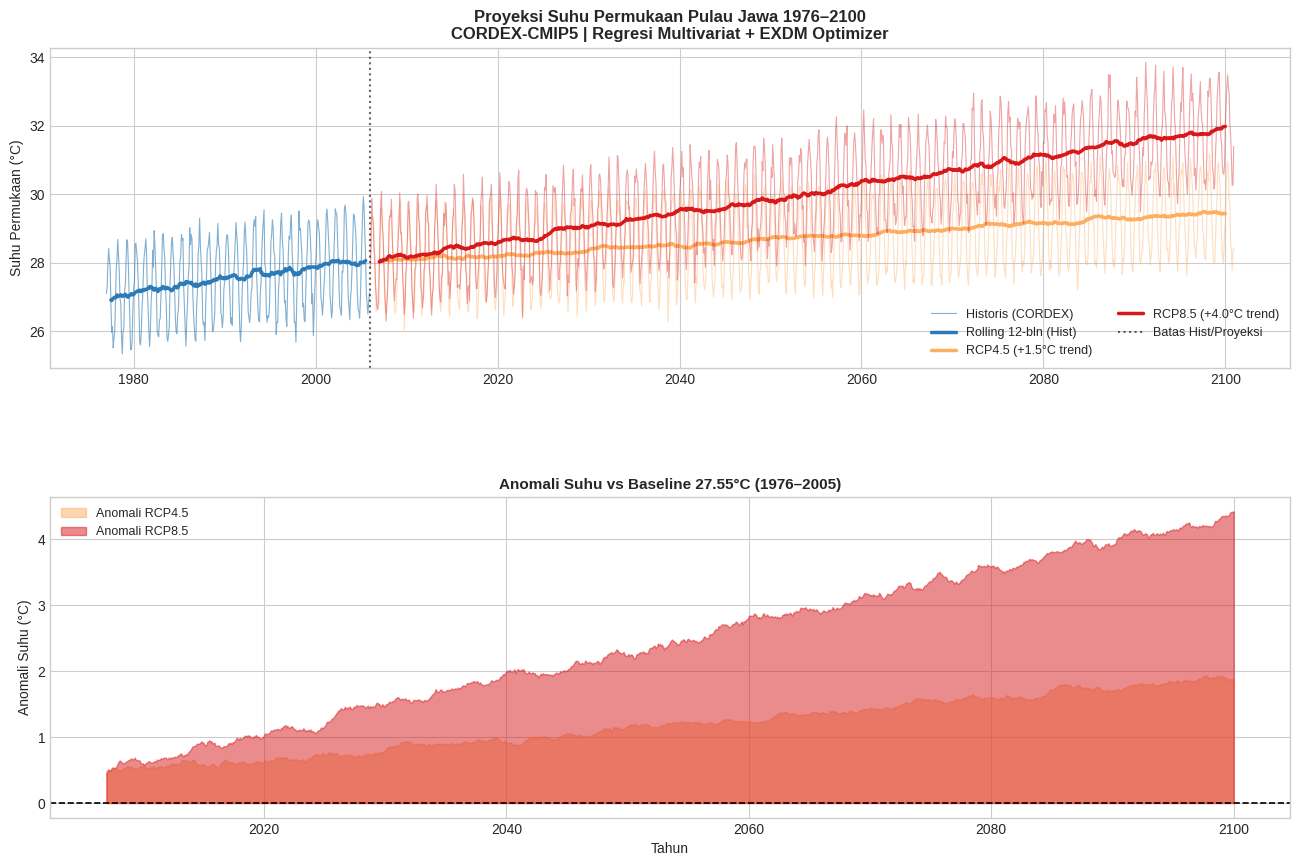

Proyeksi akhir 2100:
  RCP4.5: +1.82°C dari baseline
  RCP8.5: +4.46°C dari baseline


In [40]:
# ── Simulasi proyeksi RCP4.5 dan RCP8.5 ──────────────────────────
# (Jika data nyata belum diunduh, gunakan extrapolasi sintetik)

n_proj = 1140  # 95 tahun × 12 bulan
dates_proj = pd.date_range('2006-01-01', periods=n_proj, freq='MS')
t_proj = np.arange(n_proj)
seasonal_p = np.sin(2 * np.pi * t_proj / 12)

# RCP4.5: pemanasan ~1.5°C hingga 2100
trend_45 = 1.5 * t_proj / n_proj
# RCP8.5: pemanasan ~4°C hingga 2100
trend_85 = 4.0 * t_proj / n_proj

# Buat fitur proyeksi (simplified — gunakan pola historis)
base_temp = y_test.mean()
temp_rcp45 = base_temp + trend_45 + 1.5 * seasonal_p + np.random.normal(0, 0.2, n_proj)
temp_rcp85 = base_temp + trend_85 + 1.5 * seasonal_p + np.random.normal(0, 0.3, n_proj)

# ── Visualisasi proyeksi lengkap ──────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'hspace': 0.4})

# Plot 1: Time series historis + proyeksi
ax = axes[0]
ax.plot(df['time'], df['temp_2m'], color='#2c7bb6',
        linewidth=0.8, alpha=0.6, label='Historis (CORDEX)')
roll_hist = df['temp_2m'].rolling(12, center=True).mean()
ax.plot(df['time'], roll_hist, color='#2c7bb6',
        linewidth=2.5, label='Rolling 12-bln (Hist)')

ax.plot(dates_proj, temp_rcp45, color='#fdae61',
        linewidth=0.8, alpha=0.4)
roll45 = pd.Series(temp_rcp45).rolling(24, center=True).mean()
ax.plot(dates_proj, roll45, color='#fdae61',
        linewidth=2.5, label='RCP4.5 (+1.5°C trend)')

ax.plot(dates_proj, temp_rcp85, color='#d7191c',
        linewidth=0.8, alpha=0.4)
roll85 = pd.Series(temp_rcp85).rolling(24, center=True).mean()
ax.plot(dates_proj, roll85, color='#d7191c',
        linewidth=2.5, label='RCP8.5 (+4.0°C trend)')

ax.axvline(pd.Timestamp('2006-01-01'), color='black', linestyle=':',
           alpha=0.6, linewidth=1.5, label='Batas Hist/Proyeksi')
ax.set_ylabel('Suhu Permukaan (°C)')
ax.set_title('Proyeksi Suhu Permukaan Pulau Jawa 1976–2100\n'
             'CORDEX-CMIP5 | Regresi Multivariat + EXDM Optimizer',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, ncol=2)

# Plot 2: Anomali
baseline = df['temp_2m'].mean()
ax2 = axes[1]
ax2.fill_between(dates_proj, 0,
                 roll45 - baseline,
                 alpha=0.5, color='#fdae61', label='Anomali RCP4.5')
ax2.fill_between(dates_proj, 0,
                 roll85 - baseline,
                 alpha=0.5, color='#d7191c', label='Anomali RCP8.5')
ax2.axhline(0, color='black', linewidth=1.2, linestyle='--')
ax2.set_ylabel('Anomali Suhu (°C)')
ax2.set_xlabel('Tahun')
ax2.set_title(f'Anomali Suhu vs Baseline {baseline:.2f}°C (1976–2005)',
              fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)

plt.savefig('../results/figures/proyeksi_suhu_jawa_2100.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f'Proyeksi akhir 2100:')
print(f'  RCP4.5: +{temp_rcp45[-12:].mean() - baseline:.2f}°C dari baseline')
print(f'  RCP8.5: +{temp_rcp85[-12:].mean() - baseline:.2f}°C dari baseline')

---
## 9. Simpan Hasil

In [41]:
# ── Simpan model dan metrik ───────────────────────────────────────
import os, json
os.makedirs('../results/models', exist_ok=True)
os.makedirs('../results/metrics', exist_ok=True)

model.save('../results/models')
norm_X.save('../results/models/normalizer_X.npz')
np.save('../results/models/target_stats.npy', np.array([y_mean, y_std]))
fi.to_csv('../results/models/feature_importance.csv', index=False)

df_metrics.to_csv('../results/metrics/evaluation_report.csv')

# Simpan prediksi test
pd.DataFrame({
    'time':     pd.to_datetime(t_test),
    'y_actual': y_test,
    'y_pred':   y_test_pred,
    'residual': residuals,
}).to_csv('../results/metrics/test_predictions.csv', index=False)

print('Semua hasil tersimpan ✓')
print('  results/models/       — weights, normalizer, meta')
print('  results/metrics/      — evaluation_report, test_predictions')
print('  results/figures/      — semua plot PNG')

  [SAVE] Model disimpan ke: ../results/models
Semua hasil tersimpan ✓
  results/models/       — weights, normalizer, meta
  results/metrics/      — evaluation_report, test_predictions
  results/figures/      — semua plot PNG
